DATA LOADING AND DESCRIBING

In [1]:
# 1. Data Loading and Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Wholesale customers data.csv')


print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nDescriptive Statistics:\n", df.describe())

print("\nMissing Values:\n", df.isnull().sum())
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])


Shape: (440, 8)

Data Types:
 Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

Descriptive Statistics:
           Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.328865   7380.377175   9503.162829   
min      1.000000    1.000000       3.000000     55.000000      3.000000   
25%      1.000000    2.000000    3127.750000   1533.000000   2153.000000   
50%      1.000000    3.000000    8504.000000   3627.000000   4755.500000   
75%      2.000000    3.000000   16933.750000   7190.250000  10655.750000   
max      2.000000    3.000000  112151.000000  73498.000000  92780.000000   

             Frozen  Detergents_Paper

FEATURE ANALYSIS


Means:
 Channel                      1.322727e+00
Region                       2.543182e+00
Fresh                        1.200030e+04
Milk                         5.796266e+03
Grocery                      7.951277e+03
Frozen                       3.071932e+03
Detergents_Paper             2.881493e+03
Delicassen                   1.524870e+03
Total_Spend                  3.322614e+04
Fresh_Ratio                  3.749971e-01
Milk_Ratio                   1.675039e-01
Grocery_Ratio                2.296640e-01
Frozen_Ratio                 1.057630e-01
Detergents_Ratio             7.422198e-02
Delicassen_Ratio             4.779890e-02
Food_Spend                   2.881977e+04
NonFood_Spend                4.406364e+03
Food_to_NonFood              2.127913e+01
Fresh_Grocery_Interaction    9.399622e+07
Milk_Grocery_Interaction     9.705481e+07
dtype: float64

Medians:
 Channel                      1.000000e+00
Region                       3.000000e+00
Fresh                        8.504000e+03

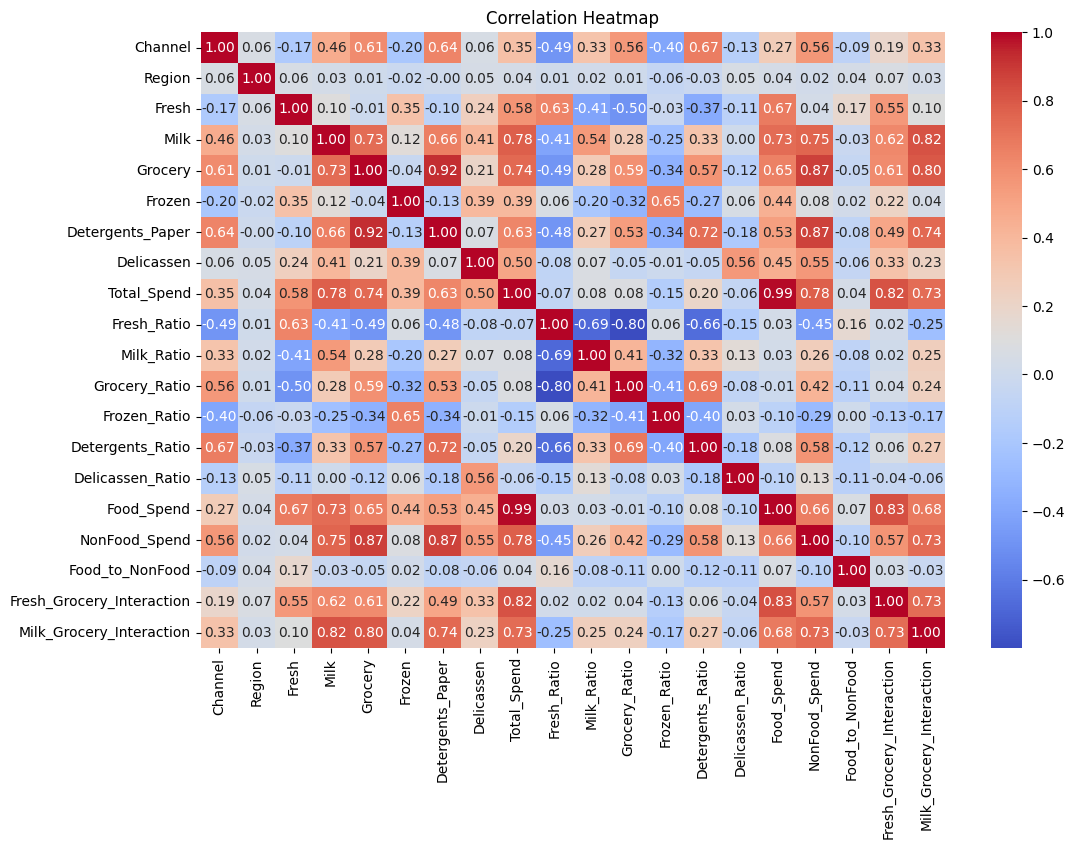


Top 5 features most correlated with target:
 Fresh_Grocery_Interaction    0.069450
Channel                      0.062028
Frozen_Ratio                 0.058622
Fresh                        0.055287
Delicassen_Ratio             0.054635
Name: Region, dtype: float64


In [9]:
# 2. Feature Analysis
numerical_features = df.select_dtypes(include=[np.number])

# Calculate stats
print("\nMeans:\n", numerical_features.mean())
print("\nMedians:\n", numerical_features.median())
print("\nStandard Deviations:\n", numerical_features.std())
print("\nQuartiles:\n", numerical_features.quantile([0.25, 0.5, 0.75]))

# Correlation matrix
corr_matrix = numerical_features.corr()

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Top 5 features most correlated with target
target = 'Region'
top_5_features = corr_matrix[target].drop(target).abs().sort_values(ascending=False).head(5)
print("\nTop 5 features most correlated with target:\n", top_5_features)



DATA VISULIZATION

In [16]:
corr_matrix

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Total_Spend,Fresh_Ratio,Milk_Ratio,Grocery_Ratio,Frozen_Ratio,Detergents_Ratio,Delicassen_Ratio,Food_Spend,NonFood_Spend,Food_to_NonFood,Fresh_Grocery_Interaction,Milk_Grocery_Interaction
Channel,1.000000,0.062028,-0.169172,0.460720,0.608792,-0.202046,0.636026,0.056011,0.351177,-0.490049,0.329669,0.557003,-0.402207,0.668927,-0.131022,0.272882,0.559220,-0.093000,0.188833,0.333894
Region,0.062028,1.000000,0.055287,0.032288,0.007696,-0.021044,-0.001483,0.045212,0.039039,0.014571,0.016059,0.006700,-0.058622,-0.026902,0.054635,0.040874,0.021110,0.037775,0.069450,0.034295
Fresh,-0.169172,0.055287,1.000000,0.100510,-0.011854,0.345881,-0.101953,0.244690,0.575178,0.634489,-0.407239,-0.496930,-0.032863,-0.374671,-0.107191,0.672862,0.035749,0.171473,0.553700,0.099506
Milk,0.460720,0.032288,0.100510,1.000000,0.728335,0.123994,0.661816,0.406368,0.776909,-0.407379,0.544617,0.277305,-0.247588,0.331296,0.004379,0.727723,0.753957,-0.033172,0.622540,0.822616
Grocery,0.608792,0.007696,-0.011854,0.728335,1.000000,-0.040193,0.924641,0.205497,0.740680,-0.486101,0.278291,0.588627,-0.337616,0.574961,-0.119967,0.653871,0.874310,-0.049737,0.608015,0.796555
Frozen,-0.202046,-0.021044,0.345881,0.123994,-0.040193,1.000000,-0.131525,0.390947,0.388436,0.058515,-0.196608,-0.319363,0.650980,-0.267947,0.057383,0.439212,0.083332,0.017752,0.218366,0.041837
Detergents_Paper,0.636026,-0.001483,-0.101953,0.661816,0.924641,-0.131525,1.000000,0.069291,0.633882,-0.484123,0.268653,0.529004,-0.337493,0.720121,-0.175100,0.528348,0.869961,-0.082498,0.490898,0.740533
Delicassen,0.056011,0.045212,0.244690,0.406368,0.205497,0.390947,0.069291,1.000000,0.496849,-0.082012,0.072435,-0.048060,-0.007252,-0.051984,0.555001,0.447414,0.552216,-0.057729,0.332185,0.231390
Total_Spend,0.351177,0.039039,0.575178,0.776909,0.740680,0.388436,0.633882,0.496849,1.000000,-0.070456,0.077565,0.083163,-0.148755,0.195645,-0.055187,0.986774,0.775338,0.037230,0.823822,0.731737
Fresh_Ratio,-0.490049,0.014571,0.634489,-0.407379,-0.486101,0.058515,-0.484123,-0.082012,-0.070456,1.000000,-0.685241,-0.799715,0.057279,-0.664036,-0.148342,0.030709,-0.445125,0.158757,0.019472,-0.254296


array([[<Axes: title={'center': 'Fresh_Grocery_Interaction'}>,
        <Axes: title={'center': 'Channel'}>],
       [<Axes: title={'center': 'Frozen_Ratio'}>,
        <Axes: title={'center': 'Fresh'}>],
       [<Axes: title={'center': 'Delicassen_Ratio'}>, <Axes: >]],
      dtype=object)

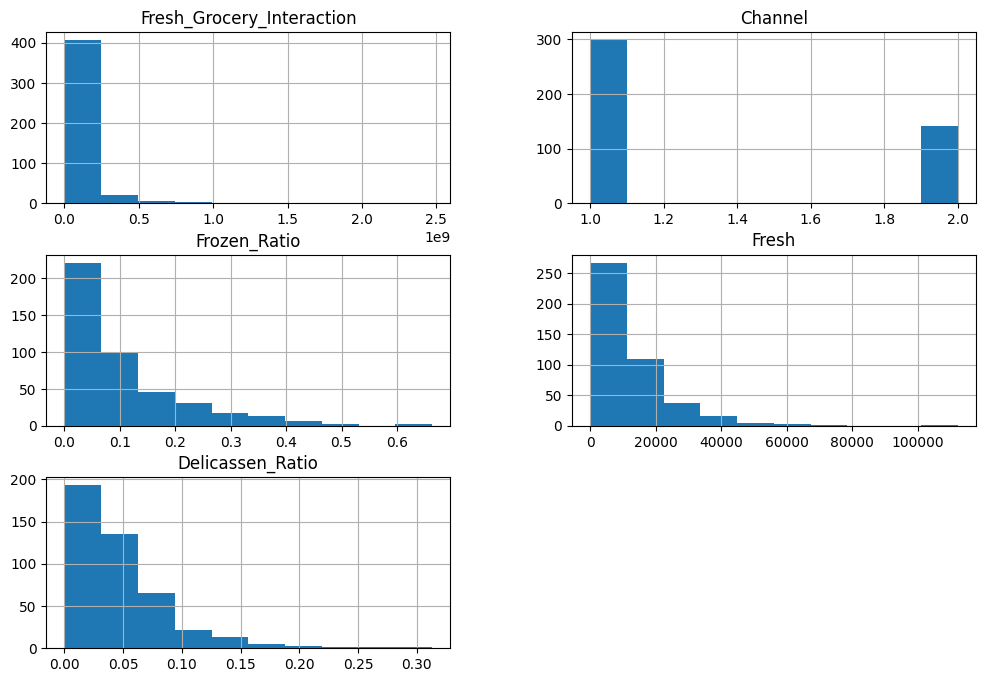

In [10]:
df[top_5_features.index.tolist()].hist(figsize=[12,8])



OR

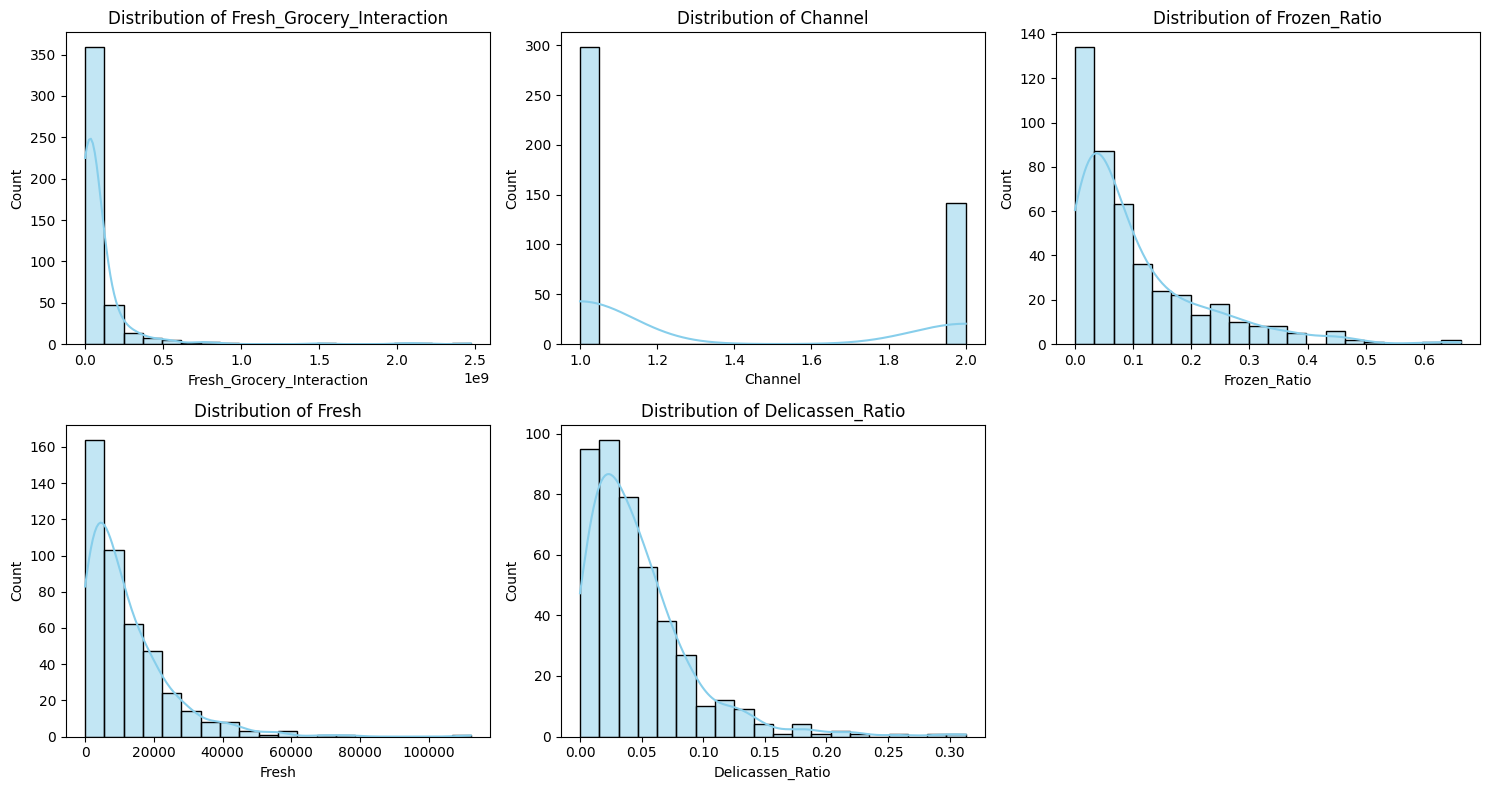

In [11]:
selected_features = top_5_features.index.tolist()

plt.figure(figsize=(15, 8))

for i, col in enumerate(selected_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=20, kde=True, color="skyblue", edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

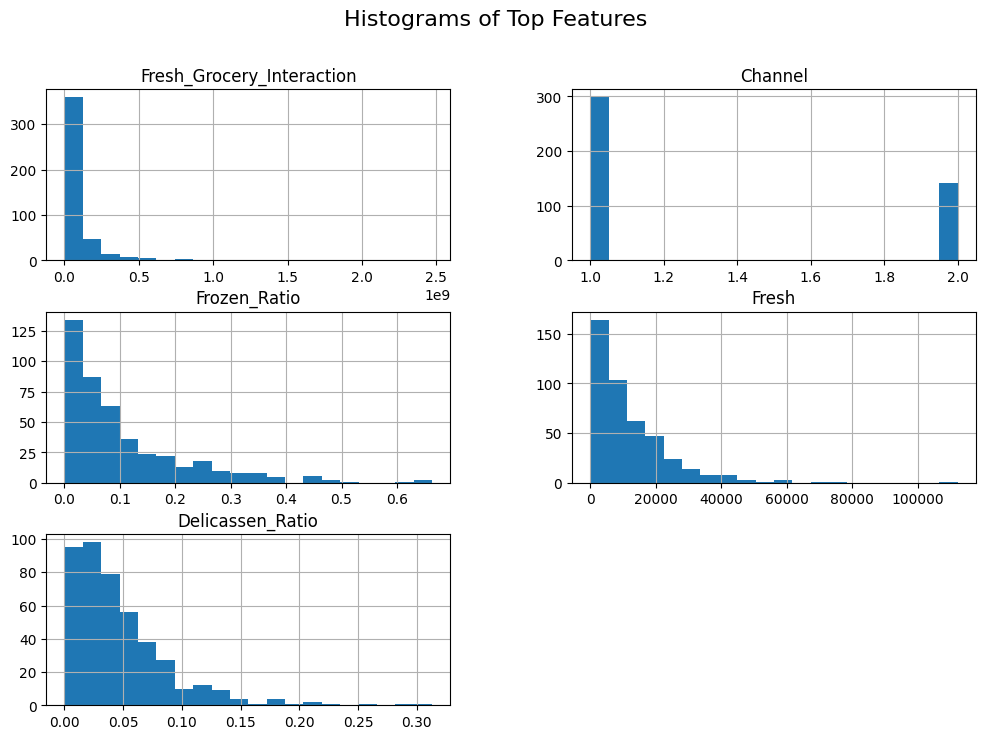

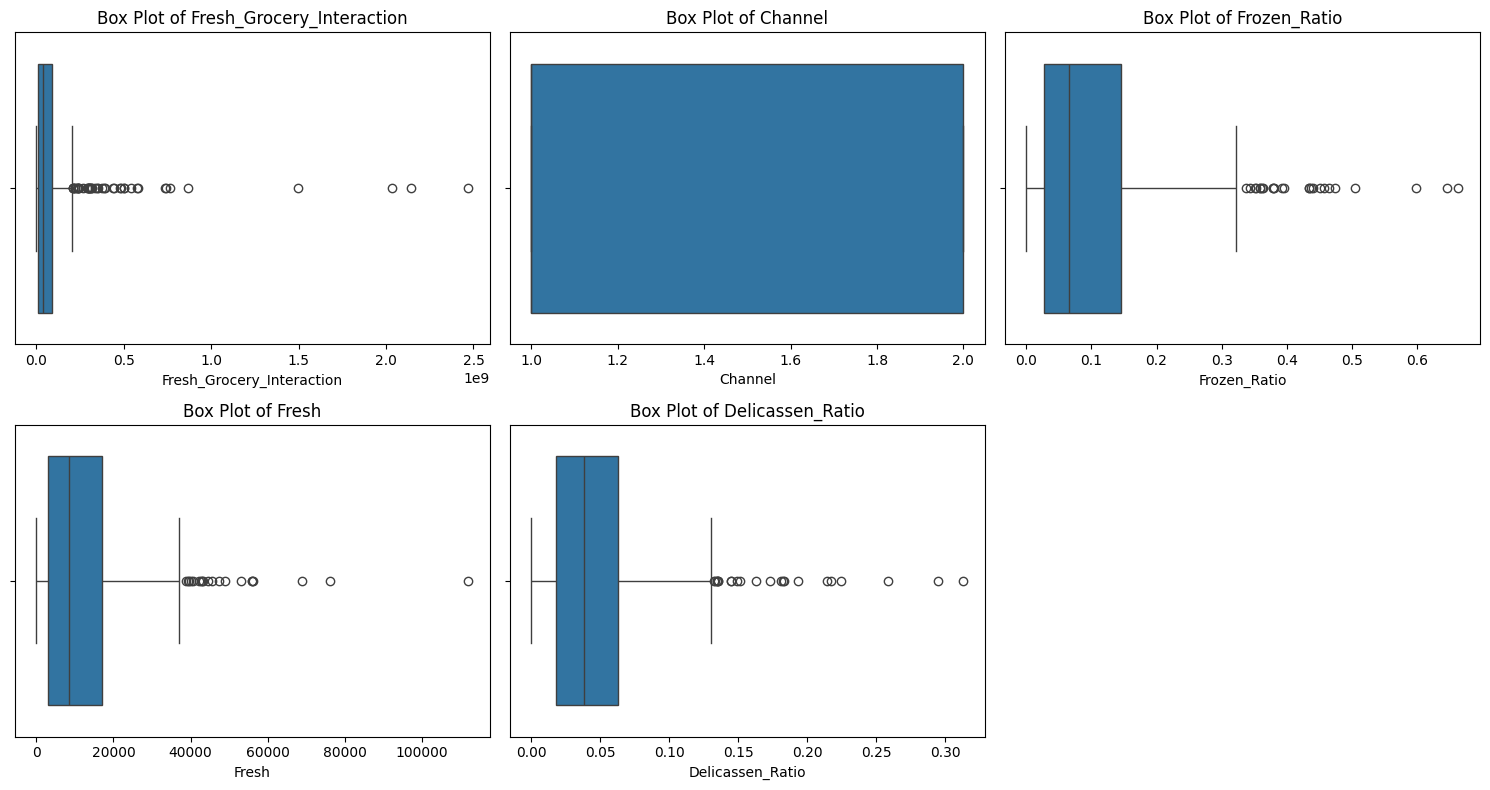

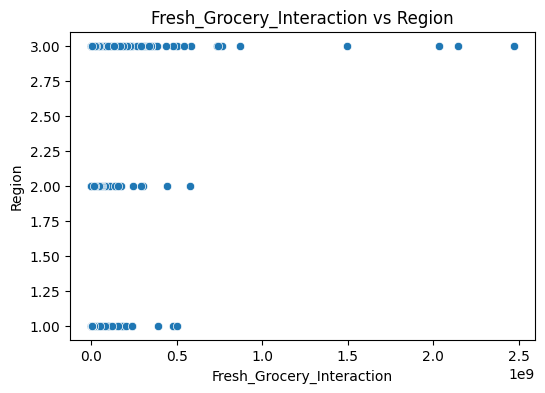

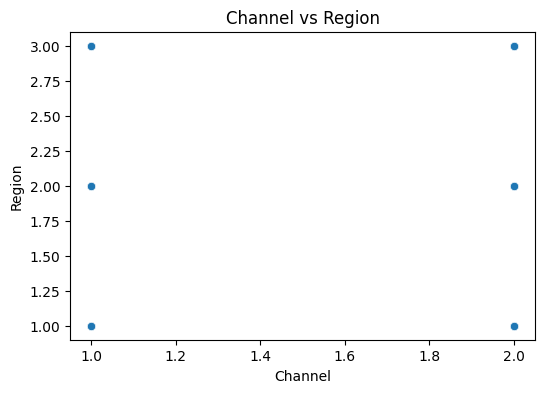

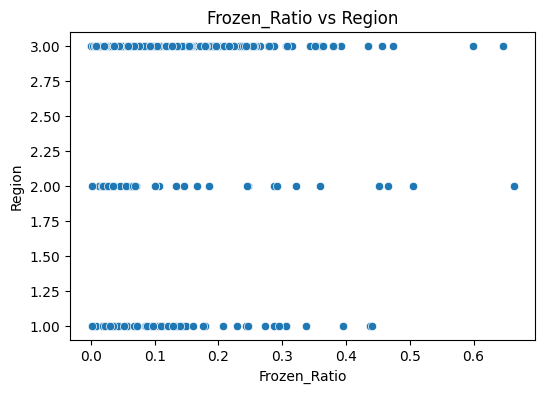

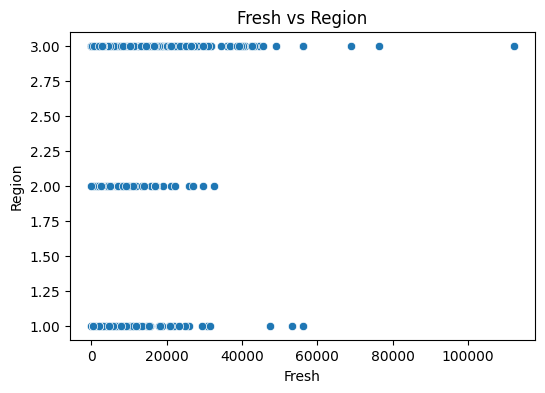

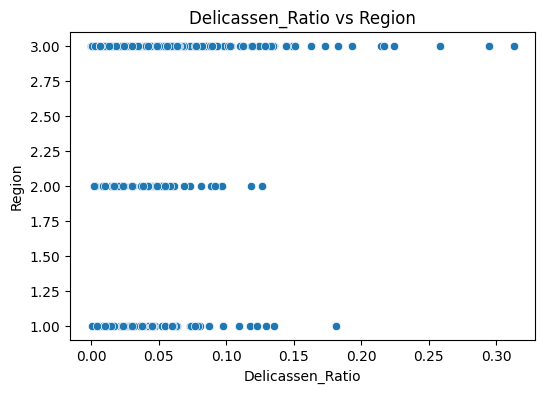

In [12]:
# 3. Data Visualization

selected_features = top_5_features.index.tolist()

# a. Histograms
df[selected_features].hist(bins=20, figsize=(12, 8))
plt.suptitle("Histograms of Top Features", fontsize=16)
plt.show()

# b. Box Plots
plt.figure(figsize=(15, 8))
for i, col in enumerate(selected_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
plt.tight_layout()
plt.show()

# c. Scatter or Bar plots with Target
if df[target].dtype in ['float64', 'int64']:
    for col in selected_features:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=df[col], y=df[target])
        plt.title(f"{col} vs {target}")
        plt.show()

# Bar plots if target is categorical
else:
    for col in selected_features:
        plt.figure(figsize=(6, 4))
        sns.barplot(x=target, y=col, data=df, palette="viridis")
        plt.title(f"{col} by {target}")
        plt.show()




FEATURE ENGINEERING

In [13]:
# Total spending across all categories
df["Total_Spend"] = (
    df["Fresh"] + df["Milk"] + df["Grocery"] +
    df["Frozen"] + df["Detergents_Paper"] + df["Delicassen"]
)

# Ratios of each category to total spend
df["Fresh_Ratio"] = df["Fresh"] / (df["Total_Spend"] + 1)
df["Milk_Ratio"] = df["Milk"] / (df["Total_Spend"] + 1)
df["Grocery_Ratio"] = df["Grocery"] / (df["Total_Spend"] + 1)
df["Frozen_Ratio"] = df["Frozen"] / (df["Total_Spend"] + 1)
df["Detergents_Ratio"] = df["Detergents_Paper"] / (df["Total_Spend"] + 1)
df["Delicassen_Ratio"] = df["Delicassen"] / (df["Total_Spend"] + 1)

# Grouping related categories
df["Food_Spend"] = df["Fresh"] + df["Milk"] + df["Grocery"] + df["Frozen"]
df["NonFood_Spend"] = df["Detergents_Paper"] + df["Delicassen"]

# Ratio of food vs non-food spending
df["Food_to_NonFood"] = df["Food_Spend"] / (df["NonFood_Spend"] + 1)

# Interaction terms (e.g., Fresh × Grocery may indicate restaurants buying both)
df["Fresh_Grocery_Interaction"] = df["Fresh"] * df["Grocery"]
df["Milk_Grocery_Interaction"] = df["Milk"] * df["Grocery"]


In [14]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Total_Spend,Fresh_Ratio,Milk_Ratio,Grocery_Ratio,Frozen_Ratio,Detergents_Ratio,Delicassen_Ratio,Food_Spend,NonFood_Spend,Food_to_NonFood,Fresh_Grocery_Interaction,Milk_Grocery_Interaction
0,2,3,12669,9656,7561,214,2674,1338,34112,0.371383,0.283059,0.221646,0.006273,0.078387,0.039223,30100,4012,7.500623,95790309,73009016
1,2,3,7057,9810,9568,1762,3293,1776,33266,0.212132,0.294887,0.287612,0.052965,0.098987,0.053386,28197,5069,5.561538,67521376,93862080
2,2,3,6353,8808,7684,2405,3516,7844,36610,0.173527,0.240583,0.209882,0.065691,0.096037,0.214253,25250,11360,2.222516,48816452,67680672
3,1,3,13265,1196,4221,6404,507,1788,27381,0.484442,0.043678,0.154152,0.233876,0.018516,0.065298,25086,2295,10.925958,55991565,5048316
4,2,3,22615,5410,7198,3915,1777,5185,46100,0.490553,0.117351,0.156135,0.084922,0.038546,0.112470,39138,6962,5.620853,162782770,38941180


CONCLUSION

In [15]:
print("## 5. Insights and Conclusions\n")

print("### a. Key Findings")
print("- Customers vary widely: some buy mostly Fresh (restaurants), others focus on Grocery + Detergents (retailers).")
print("- Grocery and Detergents_Paper are highly correlated → common in retail stores.")
print("- Fresh spending is very uneven → some extreme outliers (likely wholesalers/restaurants).")
print("- Channel and Region show clear differences in customer behavior.")

print("\n### b. Implications")
print("- Customer Segmentation:")
print("   * Retailers → high Grocery + Detergents spending.")
print("   * Restaurants → high Fresh + Milk + Frozen spending.")
print("- Business Strategy:")
print("   * Retailers may need promotions on grocery/non-food products.")
print("   * Restaurants could be targeted with fresh product deals.")
print("- Predictive Modeling:")
print("   * Ratios like Food_to_NonFood are better indicators than raw values.")

print("\n### c. Areas for Further Investigation")
print("- Apply clustering (K-Means, Hierarchical) to discover hidden customer groups.")
print("- Normalize/transform skewed spending variables (e.g., log transform).")
print("- Build classification models to predict Channel (Horeca vs Retail).")
print("- Study regional differences to guide marketing campaigns.")
print("- Investigate outliers → they could be key clients or data errors.")


## 5. Insights and Conclusions

### a. Key Findings
- Customers vary widely: some buy mostly Fresh (restaurants), others focus on Grocery + Detergents (retailers).
- Grocery and Detergents_Paper are highly correlated → common in retail stores.
- Fresh spending is very uneven → some extreme outliers (likely wholesalers/restaurants).
- Channel and Region show clear differences in customer behavior.

### b. Implications
- Customer Segmentation:
   * Retailers → high Grocery + Detergents spending.
   * Restaurants → high Fresh + Milk + Frozen spending.
- Business Strategy:
   * Retailers may need promotions on grocery/non-food products.
   * Restaurants could be targeted with fresh product deals.
- Predictive Modeling:
   * Ratios like Food_to_NonFood are better indicators than raw values.

### c. Areas for Further Investigation
- Apply clustering (K-Means, Hierarchical) to discover hidden customer groups.
- Normalize/transform skewed spending variables (e.g., log transform).
- Build class